# Recommender system

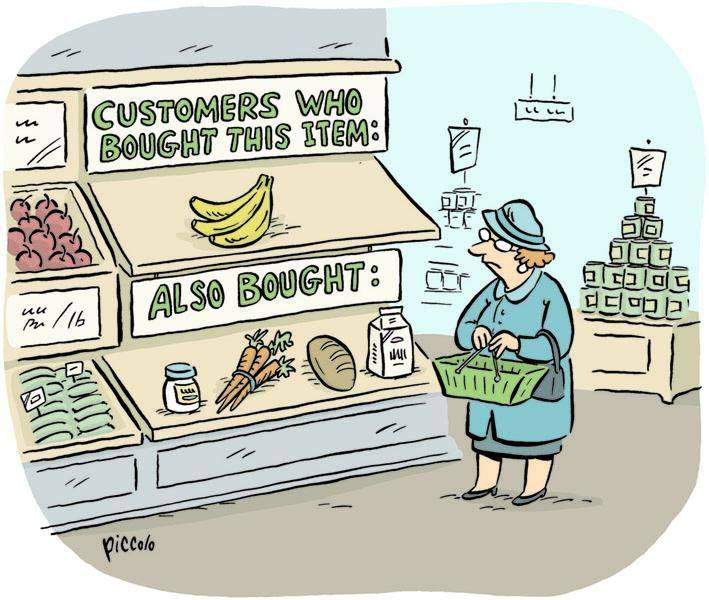

Image from: https://www.north-47.com/knowledge-base/recommendation-systems-and-collaborative-algorithm/

Recommendation is an **application** based on multiple criterias/algorithms, for example:

1. Basket analysis
2. Content based similarity
3. User based similarity (in terms of items purchased/rated), *a.k.a. Collaborative filtering*

Recommendation is a kind of **unsupervised learning**.

### Recommender systems across the world

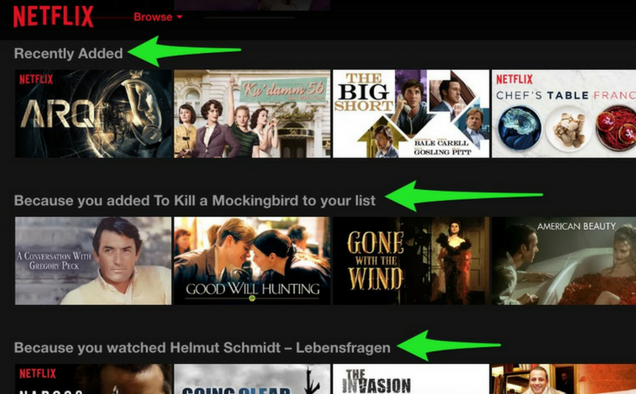

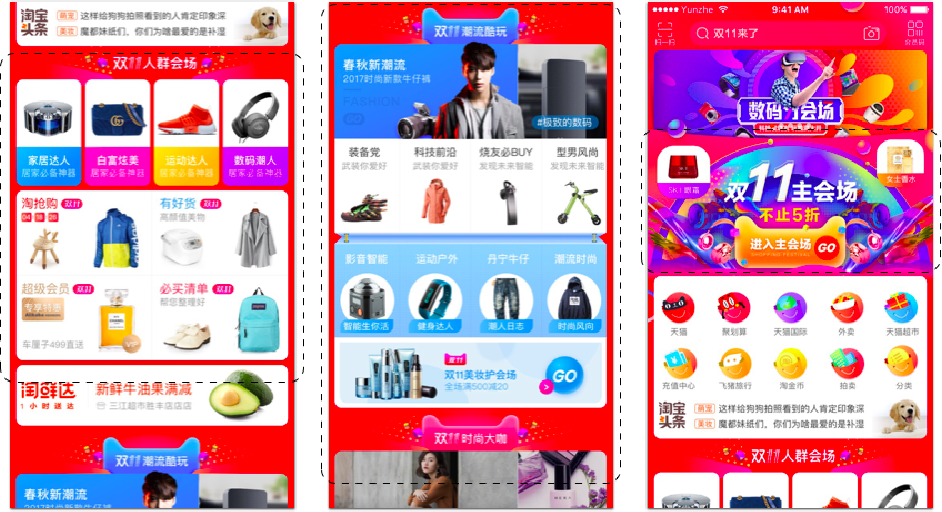

### Case Study: Recommendation in HKTVMall

https://www.hktvmall.com/hktv/zh/main/OUTING/s/H7040002/%E8%AD%B7%E7%90%86%E4%BF%9D%E5%81%A5/%E8%AD%B7%E7%90%86%E4%BF%9D%E5%81%A5/%E4%BF%9D%E5%81%A5%E7%94%A2%E5%93%81/%E5%85%92%E7%AB%A5%E5%81%A5%E5%BA%B7/%E6%93%A0%E5%A3%93%E5%BC%8F%E9%AB%94%E6%84%9F%E6%A1%8C%E4%B8%8A%E8%A8%93%E7%B7%B4%E9%9B%86%E4%B8%AD%E5%8A%9B%E9%81%8A%E6%88%B2%E8%A6%AA%E5%AD%90Autism-ADHD-ADD-SEN%E5%85%92%E7%AB%A5%E7%8E%A9%E5%85%B7-%E8%98%8B%E6%9E%9C-%E5%BD%A9%E8%99%B9%E8%89%B2/p/H7040002_S_POPITAPPLERW

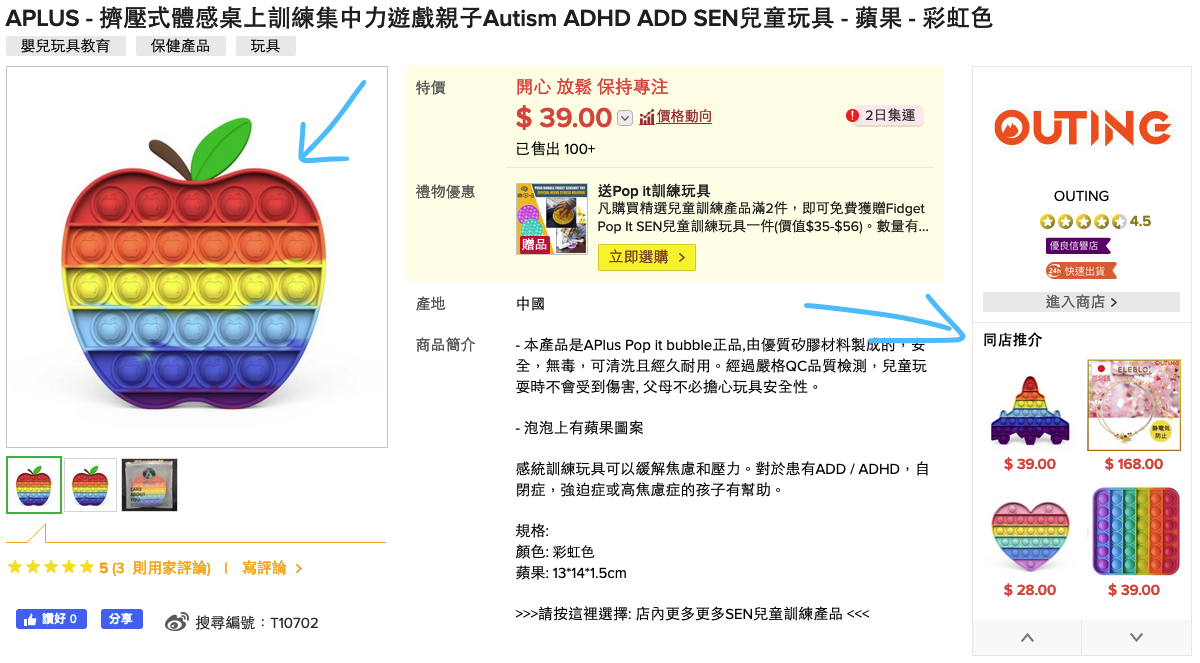

### Considerations:

1. Dilemma: Recommendation vs Editor's Pick
2. Where should we show recommendations?

### Type 1: Apriori

We perform basket analysis with the Apriori algorithm.

Datasource: https://www.kaggle.com/irfanasrullah/groceries?select=groceries+-+groceries.csv

In [1]:
# Your code here
import pandas as pd
df = pd.read_csv("https://drive.google.com/u/1/uc?id=1TNxEJWvjtyc0lOGfzaWi-H7orwEC5sfD&export=download")
df.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
baskets = []

for i, row in df.iterrows():
    number_of_items = row.loc['Item(s)']
    basket = row.iloc[1: 1 + number_of_items].to_list()
    baskets.append(basket)

In [3]:
baskets

[['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
 ['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk'],
 ['pip fruit', 'yogurt', 'cream cheese', 'meat spreads'],
 ['other vegetables',
  'whole milk',
  'condensed milk',
  'long life bakery product'],
 ['whole milk', 'butter', 'yogurt', 'rice', 'abrasive cleaner'],
 ['rolls/buns'],
 ['other vegetables',
  'UHT-milk',
  'rolls/buns',
  'bottled beer',
  'liquor (appetizer)'],
 ['potted plants'],
 ['whole milk', 'cereals'],
 ['tropical fruit',
  'other vegetables',
  'white bread',
  'bottled water',
  'chocolate'],
 ['citrus fruit',
  'tropical fruit',
  'whole milk',
  'butter',
  'curd',
  'yogurt',
  'flour',
  'bottled water',
  'dishes'],
 ['beef'],
 ['frankfurter', 'rolls/buns', 'soda'],
 ['chicken', 'tropical fruit'],
 ['butter', 'sugar', 'fruit/vegetable juice', 'newspapers'],
 ['fruit/vegetable juice'],
 ['packaged fruit/vegetables'],
 ['chocolate'],
 ['specialty bar'],
 ['other vegetables'],
 ['butter mi

#### Apriori algorithm

- Input:
    - List of basket of items
- Output
    - Associations

#### Main measurements in Apriori algorithm

- **Support**
    - A description for item popularities. i.e. How many baskets contain this item, in terms of %.
- **Confidence**
    - A description for associations. E.g. Confidence of A->B = How many people buy B given that they buy A, in terms of %.
- **Lift**
    - Lift(A->B) = The ratio Confidence(A->B)/Support(B); To describe how much better if we use the association rule.


Apriori is **not** included in any famous python packages.

However, there exist some contributors uploaded scripts to calculate the Apriori algorithm.

- https://pypi.org/project/efficient-apriori/

Try to get it working with `pip install`.

**Task**

Use the Apriori algorithm to analyse the baskets given.

How would you recommend a person who is buying `napkins`?

In [4]:
!pip install efficient-apriori


In [5]:
# Your code here
from efficient_apriori import apriori
itemsets, rules = apriori(baskets, min_support=0.01, min_confidence=0.2)

In [6]:
rules

[{beef} -> {other vegetables},
 {beef} -> {rolls/buns},
 {beef} -> {root vegetables},
 {beef} -> {whole milk},
 {beef} -> {yogurt},
 {berries} -> {other vegetables},
 {berries} -> {whole milk},
 {berries} -> {yogurt},
 {bottled beer} -> {other vegetables},
 {bottled beer} -> {soda},
 {bottled beer} -> {whole milk},
 {bottled water} -> {other vegetables},
 {bottled water} -> {rolls/buns},
 {bottled water} -> {soda},
 {bottled water} -> {whole milk},
 {bottled water} -> {yogurt},
 {brown bread} -> {other vegetables},
 {brown bread} -> {whole milk},
 {brown bread} -> {yogurt},
 {butter} -> {other vegetables},
 {butter} -> {rolls/buns},
 {butter} -> {root vegetables},
 {butter} -> {whole milk},
 {butter} -> {yogurt},
 {butter milk} -> {other vegetables},
 {butter milk} -> {whole milk},
 {chicken} -> {other vegetables},
 {chicken} -> {root vegetables},
 {chicken} -> {whole milk},
 {chocolate} -> {other vegetables},
 {chocolate} -> {rolls/buns},
 {chocolate} -> {soda},
 {chocolate} -> {whole

In [37]:
all_support_values = {key[0]: value for key, value in itemsets[1].items()}

In [46]:
all_support_values

{'citrus fruit': 814,
 'semi-finished bread': 174,
 'margarine': 576,
 'tropical fruit': 1032,
 'yogurt': 1372,
 'coffee': 571,
 'whole milk': 2513,
 'pip fruit': 744,
 'cream cheese': 390,
 'other vegetables': 1903,
 'condensed milk': 101,
 'long life bakery product': 368,
 'butter': 545,
 'rolls/buns': 1809,
 'UHT-milk': 329,
 'bottled beer': 792,
 'potted plants': 170,
 'white bread': 414,
 'bottled water': 1087,
 'chocolate': 488,
 'curd': 524,
 'flour': 171,
 'dishes': 173,
 'beef': 516,
 'frankfurter': 580,
 'soda': 1715,
 'chicken': 422,
 'sugar': 333,
 'fruit/vegetable juice': 711,
 'newspapers': 785,
 'packaged fruit/vegetables': 128,
 'specialty bar': 269,
 'butter milk': 275,
 'pastry': 875,
 'processed cheese': 163,
 'detergent': 189,
 'root vegetables': 1072,
 'frozen dessert': 106,
 'salty snack': 372,
 'waffles': 378,
 'candy': 294,
 'canned beer': 764,
 'sausage': 924,
 'brown bread': 638,
 'shopping bags': 969,
 'beverages': 256,
 'hamburger meat': 327,
 'hygiene artic

In [39]:
confidence_napkin = {}

for key, value in itemsets[2].items():
  if 'napkins' in key:
    item = (set(key) - set(['napkins'])).pop()
    confidence_napkin[item] = value

In [40]:
confidence_df = pd.DataFrame([confidence_napkin]).T
confidence_df.columns = ['Confidence']
confidence_df = confidence_df/all_support_values['napkins']
confidence_df

,Confidence
other vegetables,0.275728
rolls/buns,0.223301
soda,0.229126
tropical fruit,0.192233
whole milk,0.376699
yogurt,0.234951


In [48]:
support_df = pd.DataFrame([all_support_values]).T
support_df.columns = ['Support']
support_df = support_df/len(basket)
support_df

,Support
citrus fruit,162.8
semi-finished bread,34.8
margarine,115.2
tropical fruit,206.4
yogurt,274.4
...,...
dish cleaner,20.6
meat,50.8
mustard,23.6
liquor,21.8


In [49]:
df_conf_supp = confidence_df.join(support_df, how='left')
df_conf_supp

,Confidence,Support
other vegetables,0.275728,380.6
rolls/buns,0.223301,361.8
soda,0.229126,343.0
tropical fruit,0.192233,206.4
whole milk,0.376699,502.6
yogurt,0.234951,274.4


In [51]:
df_conf_supp['lift'] = df_conf_supp['Confidence']/df_conf_supp['Support']

In [52]:
df_conf_supp.sort_values('lift', ascending=False).head(10)

,Confidence,Support,lift
tropical fruit,0.192233,206.4,0.000931
yogurt,0.234951,274.4,0.000856
whole milk,0.376699,502.6,0.000750
other vegetables,0.275728,380.6,0.000724
soda,0.229126,343.0,0.000668
rolls/buns,0.223301,361.8,0.000617


### Type 2: Collaborative Filtering

In a context of CF, we often look at a table like the following:

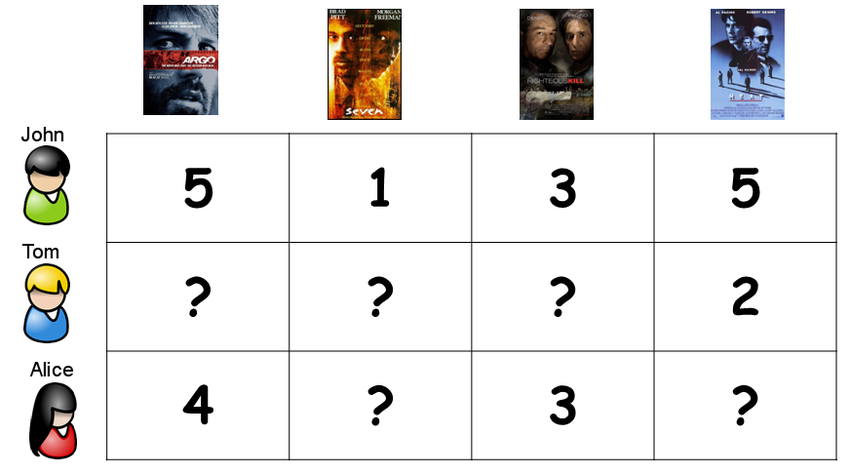

Image from: https://www.researchgate.net/figure/Example-of-user-item-ratings-matrix-in-a-movie-recommendation-scenario_fig2_300646445

#### Steps in CF:

For one particular user,
1. Treat each row in the User-Item matrix as a feature vector
2. Find k nearest neighbour using cosine similarity (Brainstorm: why cosine similarity over euclidean distance?)
3. Use the neighbours' ratings as a hint to guess the user's preference

In [7]:
# Your code here
df = pd.read_csv("https://drive.google.com/u/1/uc?id=1JPt96wvtn43ohkBYHHgn2pccfCe32X9m&export=download")
df.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [8]:
pivoted = df.pivot(index="userId", columns="movieId", values="rating")

In [9]:
pivoted

movieId,1,2,3,4,5,6,7,8,9,10,...,161084,161155,161594,161830,161918,161944,162376,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
my_ratings = {
    34: 4,
    233: 1,
    1022: 3
}

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
similarity_score = pd.DataFrame(cosine_similarity(
    (pd.concat([pivoted, pd.DataFrame([my_ratings])])  - 3 ).fillna(0)
)).iloc[-1].iloc[:-1]

In [13]:
similarity_score.index=pivoted.index
similarity_score

,671
userId,
1,0.000000
2,0.000000
3,0.000000
4,0.038035
5,0.000000
...,...
667,0.000000
668,0.000000
669,0.000000


In [14]:
top_5_similar_users = similarity_score.sort_values(ascending=False).head(5).index
top_5_similar_users

Index([495, 82, 114, 383, 192], dtype='int64', name='userId')

In [15]:
recommendation = pivoted.loc[top_5_similar_users].mean(axis=0).dropna().sort_values(ascending=False)

In [16]:
recommendation[recommendation == 5]

,0
movieId,
1,5.0
34,5.0
586,5.0
594,5.0
608,5.0
333,5.0
318,5.0
296,5.0
260,5.0


**Task**

1. Construct the User-Item matrix with `pd.pivot_table()`
2. Create a function `def predict(ratings: dict, n_neighbour=5):`


In [30]:
# 1. Construct the pivot table

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

data = {
    'user_id': [1, 1, 1, 2, 2, 3, 3, 3],
    'movie_id': [34, 233, 1022, 34, 1022, 233, 1022, 34],
    'rating': [5, 1, 3, 4, 5, 2, 3, 4]
}


df = pd.DataFrame(data)

user_item_matrix = df.pivot_table(index='user_id', columns='movie_id', values='rating')
user_item_matrix = pivoted

def predict(ratings: dict, n_neighbour=5):

    # Step 2a: Turn the dictionary into a vector
    user_vector = np.zeros(user_item_matrix.shape[1])

    # Fill in the user_vector with ratings from the input dictionary
    for movie_id, rating in ratings.items():
        if movie_id in user_item_matrix.columns:
            user_vector[user_item_matrix.columns.get_loc(movie_id)] = rating
        else:
            print(f"Warning: Movie ID {movie_id} not found in User-Item matrix.")

    # Step 2b: Compare the vector with each row in the table
    similarity_scores = cosine_similarity(user_item_matrix.fillna(0), user_vector.reshape(1, -1)).flatten()

    # Step 2c: Find the indices of top n similar users
    similar_users_indices = np.argsort(similarity_scores)[-n_neighbour:]

    # Step 2d: Calculate mean ratings of top n similar users for items not rated by the user
    similar_users_ratings = user_item_matrix.iloc[similar_users_indices]

    # Get mean rating for each movie not rated by the input user
    mean_ratings = similar_users_ratings.mean(axis=0)

    # Step 2e: Find highest scored items to recommend (excluding already rated movies)
    recommended_movies = mean_ratings[~user_item_matrix.columns.isin(ratings.keys())]

    # Sort and return top recommendations
    recommendations = recommended_movies.sort_values(ascending=False)

    return recommendations.head(n_neighbour)

# Example usage
my_ratings = {
    34: 4,
    233: 1,
    1022: 3
}

recommendations = predict(my_ratings)
print(recommendations)


movieId
596     5.0
1029    5.0
318     5.0
587     5.0
500     5.0
dtype: float64


### Type 3: Content based recommendation

Not a specific algorithm.  It depends on the item.

For example:
- Recommend music according to the genre
- Recommend goods in the same category
- Recommend readings with similar context

### Deployment

To serve the customers with the recommender system we decide

1. Where to show
    - Homepage?
    - Product detail page?
2. What is the type of recommendation
    - Content base or CF base?
    - A mixture of those?
    - Differ every time?


### Evaluation: How good is your recommendation?

Ideas:

- Click through rate
- New discoveries
- Increase in application usage

The real situation: recommendation is hard to evaluate.